In [1]:
import os
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from montecarlo import *
from scraper import *
import scraper

In [2]:
data_dir = f"data/{os.listdir("data")[-1]}" # most recent scrape
comp_dict = scraper.get_companies_dict()

In [3]:
# (x,y)
# After x days, returns must be at least y%
periods = [ 
    (30, 3),
    (90, 4.8),
    (180, 7.68),
    (270, 12.2),
    (360, 20)
]

In [4]:
# Find stocks which have been growing consistently, with low std.dev (i.e. not very volatile)

In [5]:
# A judge function must take in a df and decide whether to make a trade
# The dataframe must be ordered with last date first
def judge(df: pd.DataFrame, ticker: str) -> None | Trade:
    if len(df) >= 361 and all([df["gain"].iloc[period] > gain for (period, gain) in periods]):
        return Trade(
            ticker,
            datetime.datetime(*map(int, df.iloc[0]["date"].split('-'))),
            "Long",
            df.iloc[0]["avg"],
            5,
            5,
            5
        )
    else:
        return None

In [6]:
def clean_df(df: pd.DataFrame, cik: str):
    df = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
    df = df.iloc[::-1].reset_index(drop=True) # df[0] is now the most recent date
    df.columns = map(str.lower, df.columns)
    df["avg"] = (df["open"]+df["close"])/2
    df["gain"] = (df.iloc[0]["close"]-df["close"])/df["close"]*100 # Percentage gain from that day to the last day 
    return df

In [13]:
all_trades = []
i = 0
for cik in os.listdir(data_dir):
    if (i%100 == 0):
        print(i, len(all_trades))
    comp: Company = comp_dict[cik]
    if os.path.exists(f"{data_dir}/{cik}/ohclv.csv"):
        ohclv = pd.read_csv(f"{data_dir}/{cik}/ohclv.csv")
        if len(ohclv) > 1:
            ohclv = clean_df(ohclv, cik)
            all_trades.extend(get_trades(ohclv, lambda df: judge(df, comp.ticker)))
    i += 1


0 0
100 32901
200 68773
300 101562
400 131785


KeyboardInterrupt: 

Max drawdown: -13.355932739067491%
Worst performance: 0%
Avg std dev: 4.755644185245866
Avg. % gain per trade: 0.20308253609923224
Winrate: 62.877048646064935%
Average performance: 1724.553384038049%


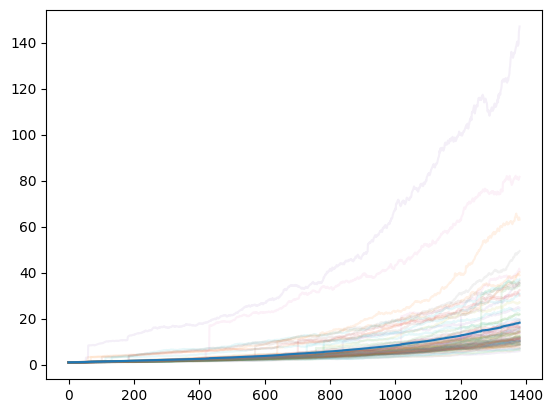

In [29]:
MonteCarlo(all_trades, 1, False).show(100)